# 07 — Clean demand aggregation

Filter to `is_clean_demand == True` and aggregate to two levels:

1. **`clean_demand_weekly`** — per (SKU × channel × DC × week_start). Weekly-grain clean-demand panel that F2 uses for scatter plots and trend-stack curves.
2. **`organic_run_rate`** — per (SKU × channel × DC). Summary statistics (mean weekly units, n_clean_weeks, low-data flag) that F1 consumes directly for its reorder math.

**Upstream:** sales_tagged_channel.parquet

**Output:** clean_demand.parquet

**Promotes to:** `src/demand.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Threshold for flagging a (SKU, channel, DC) cell as low-data. 8 clean weeks
# is ~2 months of honest observations — below that, the organic run-rate is
# too noisy for F1 to auto-fire alerts on.
LOW_DATA_WEEKS = 8

## 2. Load upstream

In [2]:
sales = pd.read_parquet(ART / 'sales_tagged_channel.parquet')

print(f'sales              : {sales.shape}')
print(f'is_clean_demand    : {sales["is_clean_demand"].sum():,} / {len(sales):,}  ({sales["is_clean_demand"].mean()*100:.1f}%)')
print(f'null SALESCHANNEL  : {sales["SALESCHANNEL"].isna().sum()}')
print(f'date range         : {sales["week_start"].min().date()}  →  {sales["week_start"].max().date()}')

sales              : (236818, 44)
is_clean_demand    : 177,778 / 236,818  (75.1%)
null SALESCHANNEL  : 4
date range         : 2023-01-02  →  2026-04-13


## 3. Do the work

In [3]:
# Aggregate clean rows into the weekly panel + organic_run_rate summary.
#
# Null DC is dropped inside `aggregate_weekly` — these rows are Shopify
# (E1), Weee (W), Returns (ZD), and a handful of U/L codes. None belong
# in F1's per-DC reorder math, so we exclude them here and surface the
# gap in the conservation check below.

from src.demand import build_clean_demand

weekly, summary, meta = build_clean_demand(sales, low_data_weeks=LOW_DATA_WEEKS)

# Quick visibility into what got dropped
clean_all = sales.loc[sales['is_clean_demand'] & sales['SALESCHANNEL'].notna()]
clean     = clean_all.loc[clean_all['DC'].notna()]
dropped_null_dc = len(clean_all) - len(clean)
dropped_qty = clean_all.loc[clean_all['DC'].isna(), 'QTY_BASE'].sum()
print(f'clean rows (any loc)  : {len(clean_all):,}')
print(f'clean rows (w/ DC)    : {len(clean):,}  (kept)')
print(f'dropped null-DC rows  : {dropped_null_dc}  ({dropped_qty:,.0f} base units)')
print(f'null-DC LOCNCODE mix  : {clean_all.loc[clean_all["DC"].isna(), "LOCNCODE"].value_counts().to_dict()}')

print(f'\nweekly panel shape : {weekly.shape}')
print(f'unique SKUs        : {weekly["ITEMNMBR"].nunique()}')
print(f'unique (SKU x chan x DC) cells: {summary.shape[0]}')

print(f'\norganic_run_rate shape: {summary.shape}')
print(f'low-data cells     : {summary["is_low_data"].sum()} / {len(summary)}  ({summary["is_low_data"].mean()*100:.1f}%)')
print(f'median n_clean_weeks : {summary["n_clean_weeks"].median():.0f}')
print(f'mean  n_clean_weeks  : {summary["n_clean_weeks"].mean():.1f}')

print(f'\nmeta: {meta}')

clean rows (any loc)  : 177,778
clean rows (w/ DC)    : 176,016  (kept)
dropped null-DC rows  : 1762  (482,213 base units)
null-DC LOCNCODE mix  : {'ZD': 995, 'E1': 456, 'W': 212, 'U': 89, 'L': 10}

weekly panel shape : (35103, 8)
unique SKUs        : 83
unique (SKU x chan x DC) cells: 568

organic_run_rate shape: (568, 11)
low-data cells     : 70 / 568  (12.3%)
median n_clean_weeks : 43
mean  n_clean_weeks  : 61.8

meta: {'low_data_weeks': 8, 'n_weekly_rows': 35103, 'n_summary_cells': 568, 'n_low_data_cells': 70}


## 4. Validate

clean QTY (any loc)   : 35,040,918.0
clean QTY (w/ DC)     : 34,558,705.0   ← what flows into weekly
weekly QTY_BASE sum   : 34,558,705.0
summary total_qty sum : 34,558,705.0
qty conservation      : OK

n_clean_weeks distribution:
count    568.000000
mean      61.801056
std       51.000441
min        1.000000
25%       16.000000
50%       43.000000
75%      109.250000
max      172.000000

low-data threshold = 8 weeks
cells < 8 weeks : 70  (12.3%)
cells >= 8 weeks: 498  (87.7%)

weekly rows & qty by channel:
              n_rows   total_qty  unique_skus  qty_share
SALESCHANNEL                                            
AM             16727   5028369.0           77   0.145502
HF              4478   2373057.0           47   0.068667
MM             13898  27157279.0           80   0.785830

--- T-32206 organic run rates ---
SALESCHANNEL DC  n_clean_weeks  mean_weekly_qty  std_weekly_qty  cv_weekly  is_low_data
          MM NJ            157     15347.929936     5562.116652   0.362402     

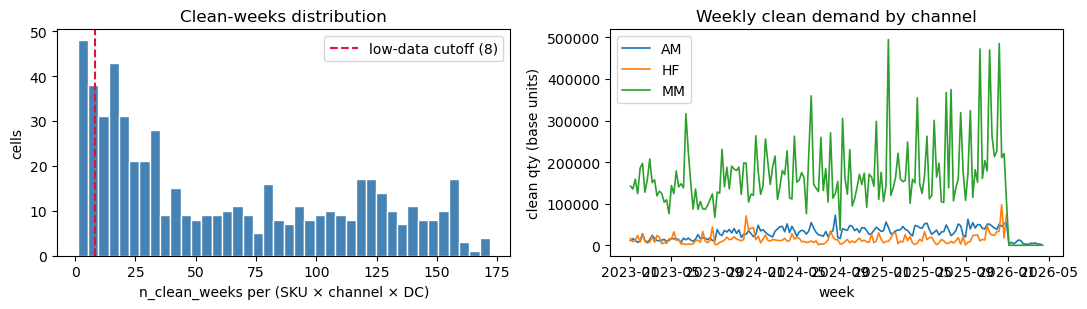

In [4]:
# ---- Check 1: unit conservation -------------------------------------------
# After dropping null-DC rows above, weekly.qty_base == summary.total_qty.
qty_clean_all = clean_all['QTY_BASE'].sum()
qty_clean_dc  = clean['QTY_BASE'].sum()
qty_weekly    = weekly['qty_base'].sum()
qty_summary   = summary['total_qty'].sum()
print(f'clean QTY (any loc)   : {qty_clean_all:,.1f}')
print(f'clean QTY (w/ DC)     : {qty_clean_dc:,.1f}   ← what flows into weekly')
print(f'weekly QTY_BASE sum   : {qty_weekly:,.1f}')
print(f'summary total_qty sum : {qty_summary:,.1f}')
assert np.isclose(qty_clean_dc, qty_weekly), 'weekly aggregation dropped units!'
assert np.isclose(qty_weekly, qty_summary), 'summary aggregation dropped units!'
print('qty conservation      : OK')

# ---- Check 2: n_clean_weeks distribution ----------------------------------
print('\nn_clean_weeks distribution:')
print(summary['n_clean_weeks'].describe().to_string())
print(f'\nlow-data threshold = {LOW_DATA_WEEKS} weeks')
print(f'cells < {LOW_DATA_WEEKS} weeks : {(summary["n_clean_weeks"] < LOW_DATA_WEEKS).sum()}  ({(summary["n_clean_weeks"] < LOW_DATA_WEEKS).mean()*100:.1f}%)')
print(f'cells >= {LOW_DATA_WEEKS} weeks: {(summary["n_clean_weeks"] >= LOW_DATA_WEEKS).sum()}  ({(summary["n_clean_weeks"] >= LOW_DATA_WEEKS).mean()*100:.1f}%)')

# ---- Check 3: channel mix of the weekly panel -----------------------------
print('\nweekly rows & qty by channel:')
ch = (weekly.groupby('SALESCHANNEL')
             .agg(n_rows=('qty_base', 'size'),
                  total_qty=('qty_base', 'sum'),
                  unique_skus=('ITEMNMBR', 'nunique')))
ch['qty_share'] = ch['total_qty'] / ch['total_qty'].sum()
print(ch.to_string())

# ---- Check 4: spot-check T-32206 (Tiger Balm Patch Warm) ------------------
print('\n--- T-32206 organic run rates ---')
spot = summary[summary['ITEMNMBR'] == 'T-32206'].sort_values('mean_weekly_qty', ascending=False)
print(spot[['SALESCHANNEL','DC','n_clean_weeks','mean_weekly_qty','std_weekly_qty','cv_weekly','is_low_data']].to_string(index=False))

# ---- Check 5: showcase SKUs quick view ------------------------------------
print('\n--- showcase SKUs: rolled-up across channels/DCs ---')
showcase = ['T-32206', 'F-04111', 'T-22010', 'T-31510']
show = (summary[summary['ITEMNMBR'].isin(showcase)]
        .groupby('ITEMNMBR')
        .agg(cells=('mean_weekly_qty', 'size'),
             low_data_cells=('is_low_data', 'sum'),
             total_weekly=('mean_weekly_qty', 'sum'),
             max_n_weeks=('n_clean_weeks', 'max')))
print(show.to_string())

# ---- Check 6: histograms --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
ax = axes[0]
ax.hist(summary['n_clean_weeks'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(LOW_DATA_WEEKS, color='crimson', linestyle='--', label=f'low-data cutoff ({LOW_DATA_WEEKS})')
ax.set_xlabel('n_clean_weeks per (SKU × channel × DC)')
ax.set_ylabel('cells')
ax.set_title('Clean-weeks distribution')
ax.legend()

ax = axes[1]
by_chan = weekly.groupby(['SALESCHANNEL', 'week_start'])['qty_base'].sum().reset_index()
for chan, grp_df in by_chan.groupby('SALESCHANNEL'):
    ax.plot(grp_df['week_start'], grp_df['qty_base'], label=chan, linewidth=1.2)
ax.set_xlabel('week')
ax.set_ylabel('clean qty (base units)')
ax.set_title('Weekly clean demand by channel')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save downstream artifact

In [5]:
weekly.to_parquet(ART / 'clean_demand_weekly.parquet')
summary.to_parquet(ART / 'organic_run_rate.parquet')

print(f'clean_demand_weekly  {weekly.shape}   -> clean_demand_weekly.parquet')
print(f'organic_run_rate     {summary.shape}  -> organic_run_rate.parquet')
print(f'\ncolumns (weekly)  : {list(weekly.columns)}')
print(f'columns (summary) : {list(summary.columns)}')

clean_demand_weekly  (35103, 8)   -> clean_demand_weekly.parquet
organic_run_rate     (568, 11)  -> organic_run_rate.parquet

columns (weekly)  : ['ITEMNMBR', 'SALESCHANNEL', 'DC', 'week_start', 'qty_base', 'revenue', 'n_txn', 'unit_price_wt']
columns (summary) : ['ITEMNMBR', 'SALESCHANNEL', 'DC', 'n_clean_weeks', 'mean_weekly_qty', 'std_weekly_qty', 'total_qty', 'first_week', 'last_week', 'cv_weekly', 'is_low_data']


## 6. Promote

Once validation above looks right, extract the core logic into `src/demand.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.